<a href="https://colab.research.google.com/github/amriT2044524/InSAR_Himalaya/blob/main/radar_and_shadow_mask_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/ASFHyP3/hyp3-sdk/blob/main/docs/sdk_example.ipynb

In [1]:
!pip install hyp3_sdk
# !pip install -U rasterio rioxarray
!pip install asf_search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.4/115.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 16.2 MB/s eta 0:00:00


In [42]:
# initial setup
import asf_search as asf
import hyp3_sdk as sdk
import glob
import os
import zipfile
import xarray as xr
import rioxarray as rxr
import pandas as pd
import numpy as np

In [9]:
# prompt for your EDL username and password
hyp3 = sdk.HyP3(prompt='password')

NASA Earthdata Login username: amrit2044
NASA Earthdata Login password: ··········


In [10]:
granules = [
    'S1A_IW_SLC__1SDV_20260115T123914_20260115T123941_062778_07DF9E_5528',
    'S1A_IW_SLC__1SDV_20260103T123915_20260103T123942_062603_07D8DE_9271',
]

rtc_jobs = sdk.Batch()
for g in granules:
    rtc_jobs += hyp3.submit_rtc_job(g, name='rtc-example')
print(rtc_jobs)

2 HyP3 Jobs: 0 succeeded, 0 failed, 0 running, 2 pending.


In [11]:
rtc_jobs = hyp3.watch(rtc_jobs)

  0%|          | 0/2 [timeout in 10800 s]

In [12]:
file_list = rtc_jobs.download_files()

  0%|          | 0/2 [00:00<?, ?it/s]

S1A_IW_20260115T123914_DVR_RTC30_G_gpuned_6137.zip:   0%|          | 0/463387518 [00:00<?, ?it/s]

S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4.zip:   0%|          | 0/463167400 [00:00<?, ?it/s]

In [33]:
zip_files = glob.glob("*.zip")
zip_files


['S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4.zip',
 'S1A_IW_20260115T123914_DVR_RTC30_G_gpuned_6137.zip']

In [37]:
names_no_zip = [os.path.splitext(f)[0] for f in zip_files]
names_no_zip

['S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4',
 'S1A_IW_20260115T123914_DVR_RTC30_G_gpuned_6137']

In [64]:
i=0

In [65]:
zip_path = f"{names_no_zip[i]}.zip"
out_dir = f"{names_no_zip[i]}"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

# list files
os.listdir(out_dir)


['S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4']

In [67]:
tif_shadow=f"/content/{out_dir}/{out_dir}/{names_no_zip[i]}_ls_map.tif"
tif_shadow

'/content/S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4/S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4/S1A_IW_20260103T123915_DVP_RTC30_G_gpuned_EEC4_ls_map.tif'

In [68]:
da = rxr.open_rasterio(tif_shadow)
da


<xarray.DataArray (band: 1, y: 7582, x: 9766)> Size: 74MB
[74045812 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 61kB 3.434e+06 3.434e+06 ... 3.206e+06 3.206e+06
  * x            (x) float64 78kB 3.443e+05 3.443e+05 ... 6.372e+05 6.372e+05
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:  Created with GAMMA Software www.gamma-rs.ch data2geoti...
    TIFFTAG_DATETIME:  2026:01:26 23:23:07
    AREA_OR_POINT:     Point
    _FillValue:        0
    scale_factor:      1.0
    add_offset:        0.0

In [12]:
# da.plot()

In [70]:
import rioxarray as rxr
from pyproj import Transformer
from rasterio.enums import Resampling

# WGS84 bbox (lon/lat), define AOI
lon_min, lon_max, lat_min, lat_max = 81.3998, 82.16178, 29.7501, 30.51603

# 1) Ensure da has CRS (must not be None)
print("da CRS:", da.rio.crs)
# If None, you MUST set it correctly first, e.g.:
# da = da.rio.write_crs("EPSG:32644")  # <-- example, replace with correct CRS

src_crs = da.rio.crs
dst_crs = "EPSG:4326"

# 2) Transform bbox corners from EPSG:4326 -> da CRS
tfm = Transformer.from_crs(dst_crs, src_crs, always_xy=True)

x1, y1 = tfm.transform(lon_min, lat_min)
x2, y2 = tfm.transform(lon_max, lat_max)

minx, maxx = sorted([x1, x2])
miny, maxy = sorted([y1, y2])

da CRS: EPSG:32644


In [71]:
# 3) Crop in native projection (fast)
da_crop_native = da.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)


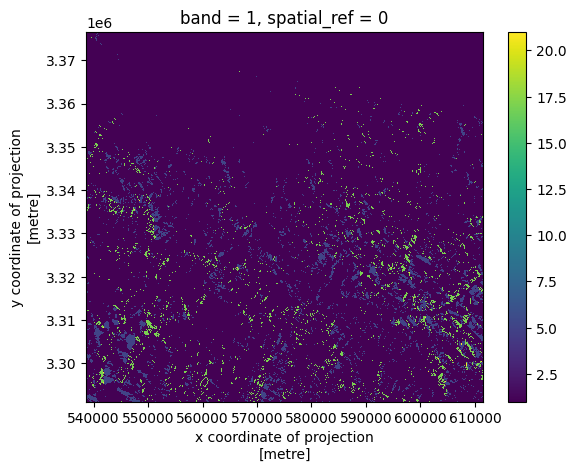

In [72]:
da_crop_native.plot()

In [73]:
# 4) Reproject the cropped raster back to WGS84
da_crop_wgs84 = da_crop_native.rio.reproject(dst_crs, resampling=Resampling.nearest)
da_crop_wgs84

<xarray.DataArray (band: 1, y: 2689, x: 2644)> Size: 7MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 22kB 30.52 30.52 30.52 30.52 ... 29.75 29.75 29.75
  * x            (x) float64 21kB 81.4 81.4 81.4 81.4 ... 82.16 82.16 82.16
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:  Created with GAMMA Software www.gamma-rs.ch data2geoti...
    TIFFTAG_DATETIME:  2026:01:26 23:23:07
    AREA_OR_POINT:     Point
    scale_factor:      1.0
    add_offset:        0.0
    _FillValue:        0

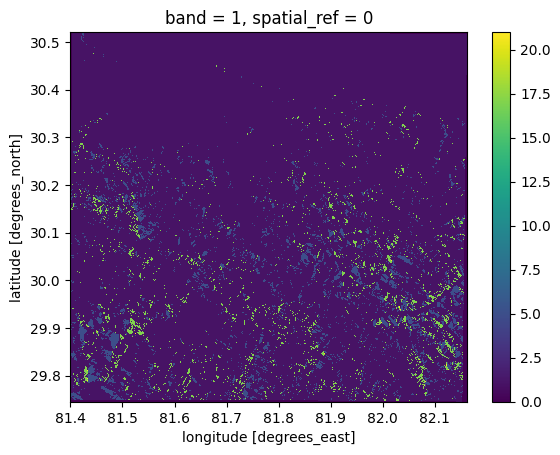

In [74]:
da_crop_wgs84.plot()

In [75]:
df = da_crop_wgs84.to_dataframe(name="value").reset_index()
df.head()


,band,y,x,spatial_ref,value
0,1,30.520606,81.399880,0,0
1,1,30.520606,81.400168,0,0
2,1,30.520606,81.400456,0,0
3,1,30.520606,81.400745,0,0
4,1,30.520606,81.401033,0,0


In [76]:
df["value"].dropna().unique().tolist()

[0, 1, 5, 17, 21]

value=c(1,5,17,21)

desc=c('No Layover/Shadow','Layover','Shadow','Layover+Shadow'))


In [77]:
shadow_layover_mask = (da_crop_wgs84 == 1).astype("uint8")

In [78]:
np.unique(shadow_layover_mask.values)

array([0, 1], dtype=uint8)

In [79]:
from google.colab import files

out_file = f"shadow_layover_mask_{names_no_zip[i]}.tif"
shadow_layover_mask.rio.to_raster(out_file)
files.download(out_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

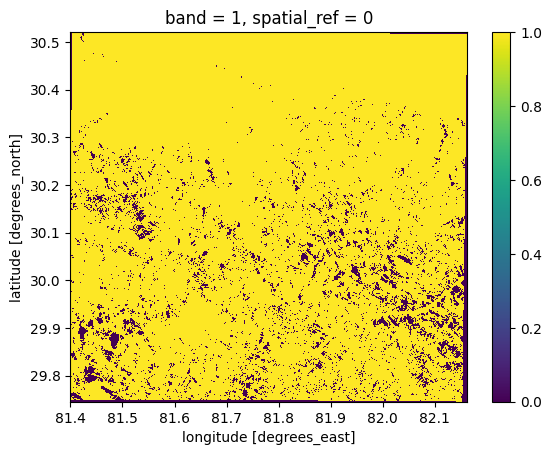

In [62]:
shadow_layover_mask.plot()


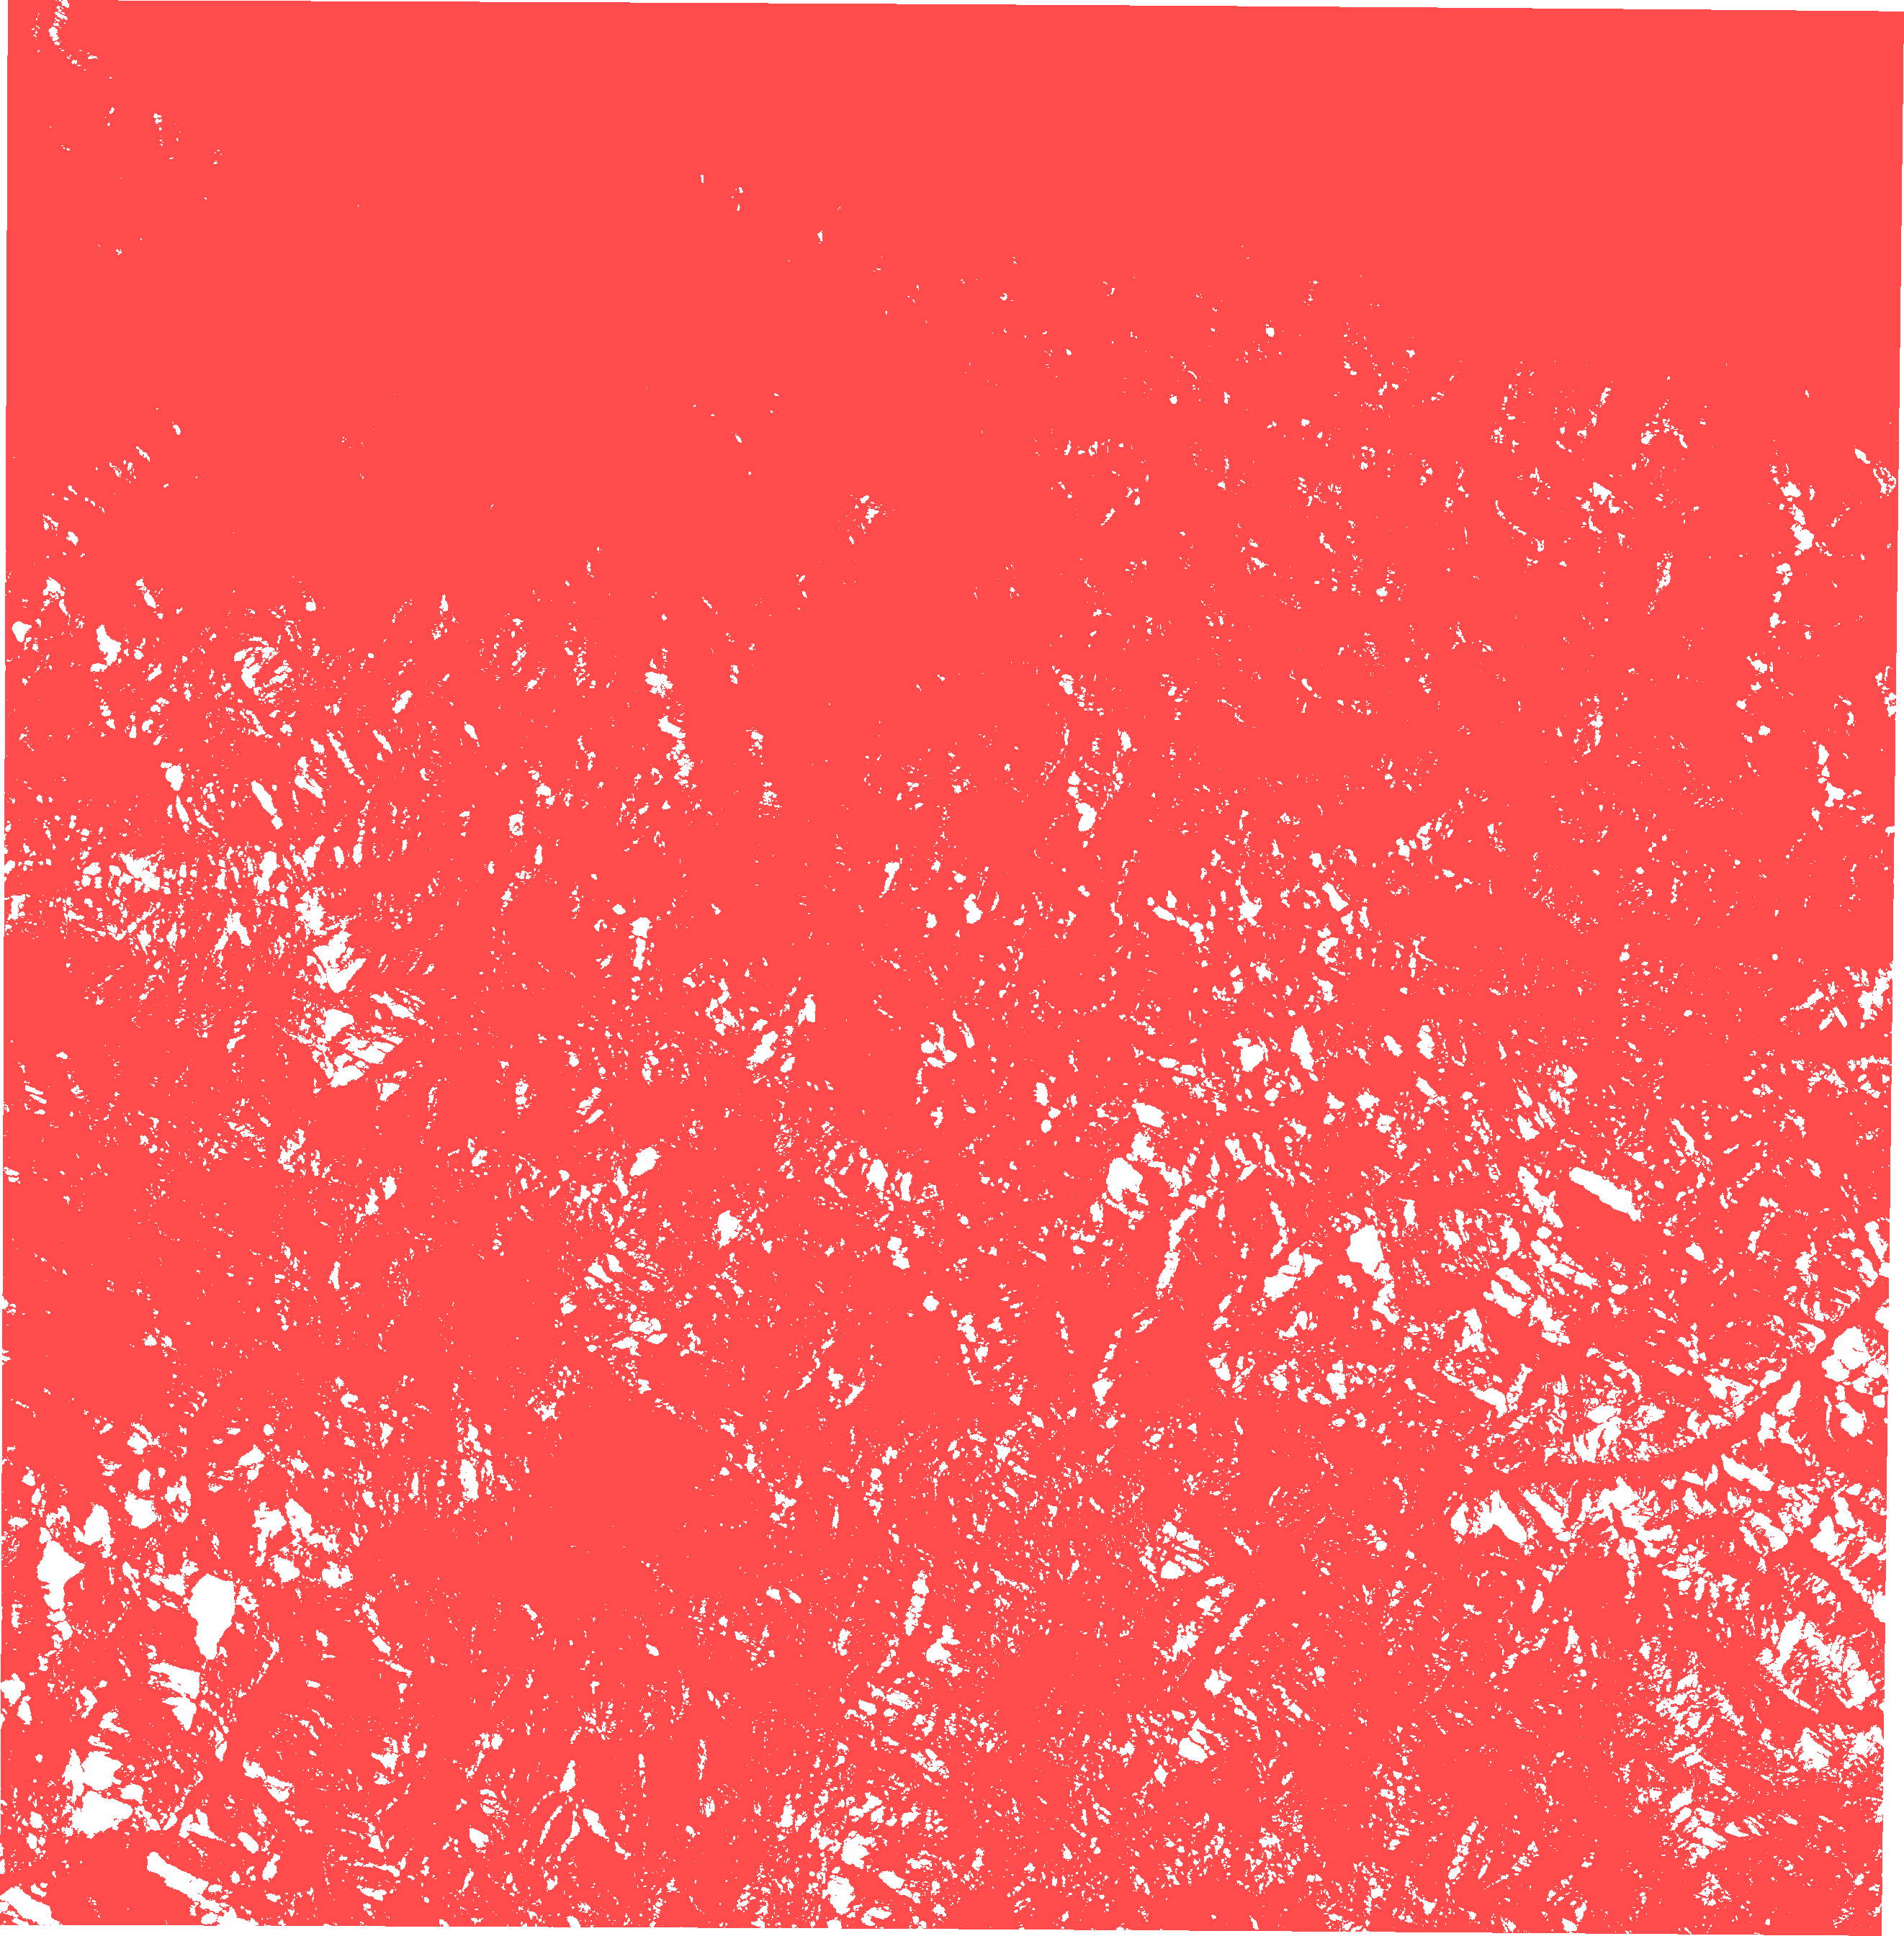

In [63]:
import numpy as np
import folium

# --- ensure 2D mask array ---
arr = np.asarray(shadow_layover_mask.values)
if arr.ndim == 3:
    arr = arr[0]  # (y, x)
arr = (arr == 1).astype(np.uint8)  # force binary 0/1

# --- create RGBA image ---
rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=np.uint8)
rgba[..., 0] = 255                 # Red channel
rgba[..., 3] = arr * 180           # Alpha: 0 for 0s, ~70% for 1s (0-255)

# bounds
bounds = [
    [float(shadow_layover_mask.y.min()), float(shadow_layover_mask.x.min())],
    [float(shadow_layover_mask.y.max()), float(shadow_layover_mask.x.max())]
]

# map
lat0 = float(shadow_layover_mask.y.mean())
lon0 = float(shadow_layover_mask.x.mean())
# m = folium.Map(location=[lat0, lon0], zoom_start=9, tiles="OpenStreetMap")
m = folium.Map(location=[lat0, lon0], zoom_start=9, tiles="Esri.WorldImagery")


folium.raster_layers.ImageOverlay(
    image=rgba,
    bounds=bounds,
    opacity=1.0,   # keep 1.0 because alpha is handled in RGBA
).add_to(m)

m


## 6. Layover-shadow mask <read read me file >

The layover/shadow mask indicates which pixels in the RTC image have been affected by layover and shadow. This layer is always included in the product package, and is tagged with _ls_map.tif

The pixel values are generated by adding the following values together to indicate which layover and shadow effects are impacting each pixel:
0  Pixel not tested for layover or shadow

1  Pixel tested for layover or shadow

2  Pixel has a look angle less than the slope angle

4  Pixel is in an area affected by layover

8  Pixel has a look angle less than the opposite of the slope angle

16 Pixel is in an area affected by shadow

There are 17 possible different pixel values, indicating the layover, shadow, and slope conditions present added together for any given pixel._

**The values in each cell can range from 0 to 31:**
0  Not tested for layover or shadow
1  Not affected by either layover or shadow
3  Look angle < slope angle
5  Affected by layover
7  Affected by layover; look angle < slope angle
9  Look angle < opposite slope angle
11 Look angle < slope and opposite slope angle
13 Affected by layover; look angle < opposite slope angle
15 Affected by layover; look angle < slope and opposite slope angle
17 Affected by shadow
19 Affected by shadow; look angle < slope angle
21 Affected by layover and shadow
23 Affected by layover and shadow; look angle < slope angle
25 Affected by shadow; look angle < opposite slope angle
27 Affected by shadow; look angle < slope and opposite slope angle
29 Affected by shadow and layover; look angle < opposite slope angle
31 Affected by shadow and layover; look angle < slope and opposite slope angle

-------------

https://hyp3-docs.asf.alaska.edu/guides/rtc_product_guide/#image-files